In [1]:
import os
import subprocess
import baltic as bt
import pandas as pd
import json
from io import StringIO as sio
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from collections import Counter

/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



Tree height: 0.273127
Tree length: 15.530014
annotations present

Numbers of objects in tree: 15977 (6761 nodes and 9216 leaves)



/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_26086/1058087691.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab20', len(unique_clades))


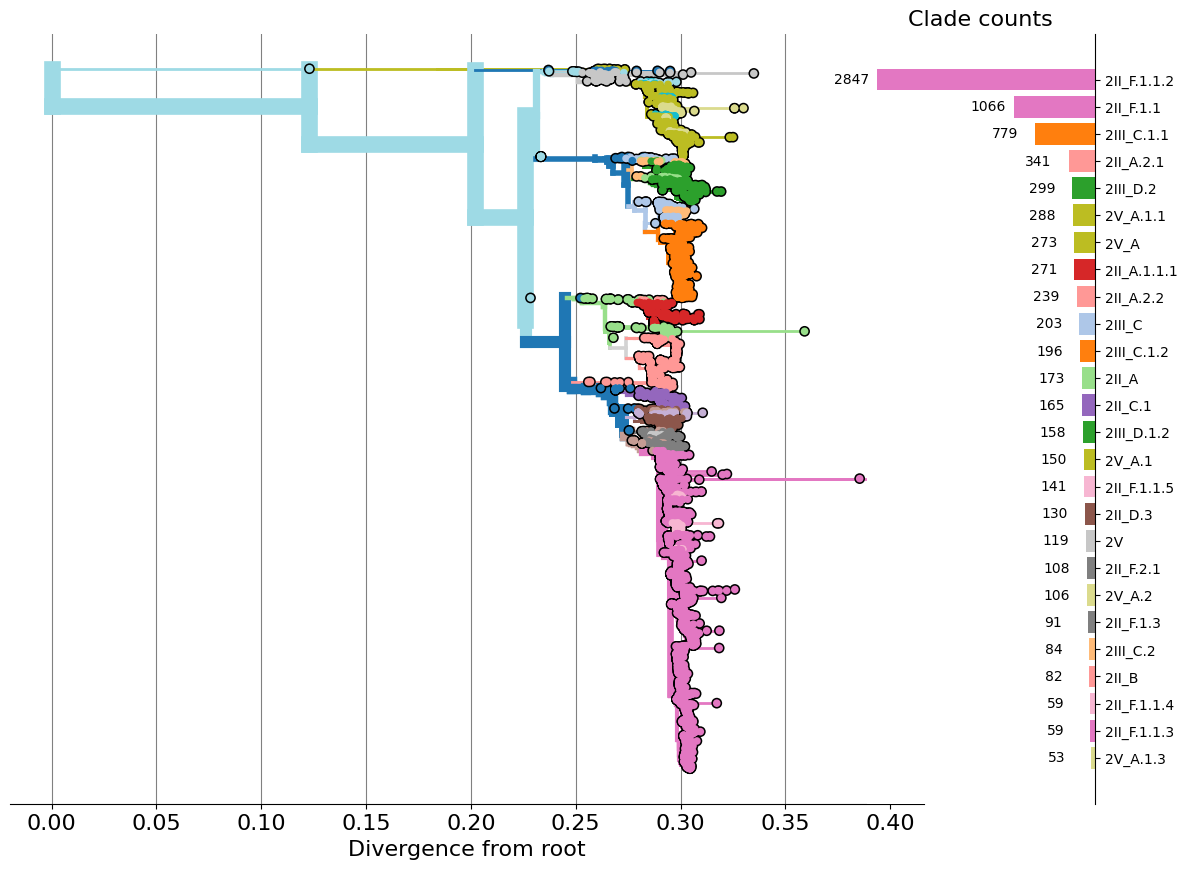

In [2]:
D3_nextstrain = '../Data/D2/D2gisaid_arbo_2025_04_24_18/nextclade.auspice.json'

def prune(node, thresh=0.15):
    # only operate on dict-nodes
    if not isinstance(node, dict):
        return node
    # get the divergence (a float) for *this* branch
    div = node.get('node_attrs', {}) .get('div')
    if div is not None and div > thresh:
        return None
    # otherwise prune children
    if 'children' in node:
        kept = []
        for child in node['children']:
            pc = prune(child, thresh)
            if pc is not None:
                kept.append(pc)
        node['children'] = kept
    return node

# 1) Read the file
with open(D3_nextstrain, 'r') as fh:
    nx_json = json.load(fh)


# 2) Tell baltic to use 'div' as the node height
json_translation = {
    'absoluteTime': lambda node: node.traits['node_attrs']['div'],
    'name': 'name'
}

# 3) Load into baltic
ll, meta = bt.loadJSON(nx_json, json_translation=json_translation)

# make figure with tree on left and barplot on right
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=-0.1)
ax_tree = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])


L=len(list(filter(lambda k: k.branchType=='leaf',ll.Objects)))

clade_list = [
    k.traits['node_attrs']
      .get('clade_membership', {})
      .get('value')
    for k in ll.Objects if k.is_leaf()
]

# create a unique sorted list and assign colors from tab20
unique_clades = sorted({c for c in clade_list if c is not None})
palette = cm.get_cmap('tab20', len(unique_clades))
clade_color_map = {
    clade: mcolors.to_hex(palette(i))
    for i, clade in enumerate(unique_clades)
}

# register this map under 'clade_membership'
ll.cmap['clade_membership'] = clade_color_map

clade_counts = Counter(
    node.traits['node_attrs']['clade_membership']['value']
    for node in ll.Objects if node.is_leaf()
)
filtered = {clade: cnt for clade, cnt in clade_counts.items() if cnt >= 50}
clades, counts = zip(*sorted(filtered.items(), key=lambda x: x[1], reverse=True))
colors = [ll.cmap['clade_membership'][c] for c in clades]

# colour function using the newly registered map
def c_func(node):
    clade = node.traits['node_attrs'] \
               .get('clade_membership', {}) \
               .get('value')
    return ll.cmap['clade_membership'].get(clade, 'lightgrey')


x_attr = lambda k: k.absoluteTime
b_func=lambda k: 2+10.0*len(k.leaves)/float(L) if k.branchType=='node' else 2

# plotting
ll.plotTree(ax_tree, x_attr=x_attr, width=b_func, colour=c_func, zorder=20000)
ll.plotPoints(ax_tree, x_attr=x_attr, size=30, colour=c_func, zorder=20002)
for loc in ['left', 'right', 'top']:
    ax_tree.spines[loc].set_visible(False)
ax_tree.grid(axis='x', ls='-', color='grey')
ax_tree.tick_params(axis='y', size=0)
ax_tree.tick_params(axis='x', labelsize=16)
ax_tree.set_xlabel('Divergence from root', fontsize=16)
ax_tree.set_yticklabels([])

y = np.arange(len(clades))
ax_bar.barh(y, counts, color=colors)
ax_bar.set_yticks(y)
ax_bar.set_yticklabels(clades, fontsize=10)
ax_bar.invert_yaxis()

# move y‐labels to the right
ax_bar.yaxis.tick_right()
ax_bar.yaxis.set_label_position('right')
ax_bar.title.set_text('Clade counts')
ax_bar.title.set_size(16)
# make bars extend left
ax_bar.set_xlim(max(counts)*1.05, 0)

# annotate counts at end of each bar
offset = max(counts) * 0.2
for i, count in enumerate(counts):
    ax_bar.text(count + offset, i, str(count),
                va='center', ha='left', fontsize=10)

# drop x‐axis
ax_bar.xaxis.set_visible(False)
for loc in ['bottom', 'top', 'left']:
    ax_bar.spines[loc].set_visible(False)


#
#plt.savefig('../Figures/Supplementary/Dengue2_global.jpeg', dpi = 1200, bbox_inches='tight')
plt.show()

In [13]:
#D3 E gene
from Bio import SeqIO

in_fasta  = "../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.cds_translation.E.fasta"
out_fasta = "../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.cds_translation_Colombia.E.fasta"


filtered = []
for rec in SeqIO.parse(in_fasta, "fasta"):
    # header format assumed: ><accession>/<country>/...
    parts = rec.id.split("/")
    if len(parts) > 1 and parts[1] == "Colombia":
        filtered.append(rec)

# 3) Write filtered sequences
SeqIO.write(filtered, out_fasta, "fasta")
print(f"Wrote {len(filtered):d} records to {out_fasta!r}")

Wrote 136 records to '../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.cds_translation_Colombia.E.fasta'


/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_26086/201020712.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette      = cm.get_cmap("tab20", len(valid_clades))


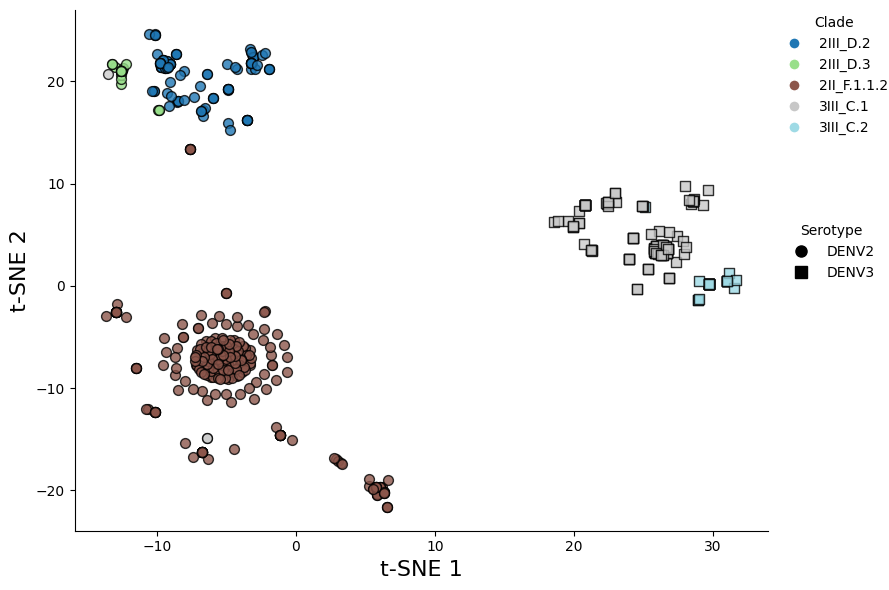

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from sklearn.manifold import TSNE
from matplotlib import cm, colors

# ————————————————
# 1) Load sequences & metadata
# ————————————————
# DENV-2
records2 = list(SeqIO.parse("../Data/D2/Col_only/nextclade.cds_translation.E.fasta","fasta"))
names2   = [r.id for r in records2]
seqs2    = np.array([list(str(r.seq)) for r in records2])
meta2    = pd.read_csv("../Data/D2/Col_only/nextclade.csv",
                       usecols=["seqName","clade"], sep=";",
                       dtype=str, on_bad_lines="skip")
meta2["serotype"] = "DENV2"

# DENV-3
records3 = list(SeqIO.parse("../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.cds_translation_Colombia.E.fasta","fasta"))
names3   = [r.id for r in records3]
seqs3    = np.array([list(str(r.seq)) for r in records3])
meta3    = pd.read_csv("../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.csv",
                       usecols=["seqName","clade"], sep=";",
                       dtype=str, on_bad_lines="skip")
meta3 = meta3[meta3["seqName"].str.contains("Colombia")].copy()
meta3["serotype"] = "DENV3"

# Combine names, sequences, and metadata
names = names2 + names3

# pad sequences so they’re all the same length
L = max(seqs2.shape[1], seqs3.shape[1])
def pad_to(seqs, L):
    n, l = seqs.shape
    if l < L:
        pad = np.full((n, L-l), "-", dtype=seqs.dtype)
        return np.hstack([seqs, pad])
    return seqs
seqs2 = pad_to(seqs2, L)
seqs3 = pad_to(seqs3, L)
seqs  = np.vstack([seqs2, seqs3])

metadata = pd.concat([meta2, meta3], ignore_index=True).set_index("seqName")

# ————————————————————————
# 2) Compute pairwise distances
# ————————————————————————
n = len(names)
D = np.zeros((n,n))
for i in range(n):
    for j in range(i+1, n):
        s1, s2 = seqs[i], seqs[j]
        mask   = (s1 != "-") & (s2 != "-")
        d      = np.sum(s1[mask] != s2[mask]) / np.sum(mask)
        D[i,j] = D[j,i] = d

# ————————————
# 3) t-SNE embed
# ————————————
tsne   = TSNE(n_components=2, metric="precomputed", init="random",
              perplexity=30, random_state=0)
coords = tsne.fit_transform(D)

# ————————————————————————
# 4) Build clade colour map (only clades ≥5)
# ————————————————————————
clade_counts  = metadata["clade"].value_counts()
valid_clades  = clade_counts[clade_counts >= 10].index.sort_values()
palette      = cm.get_cmap("tab20", len(valid_clades))
clade_colors = {
    cl: colors.to_hex(palette(i))
    for i, cl in enumerate(valid_clades)
}

# ————————————————————————————————
# 5) Plot points coloured by clade & shaped by serotype
# ————————————————————————————————
fig, ax = plt.subplots(figsize=(9,6))

# serotype→marker mapping
marker_map = {"DENV2": "o", "DENV3": "s"}

# loop through all points
for idx, name in enumerate(names):
    ser   = metadata.at[name, "serotype"]
    clade = metadata.at[name, "clade"]
    color = clade_colors.get(clade, "#CCCCCC")  # grey if rare
    ax.scatter(coords[idx,0],
               coords[idx,1],
               c=color,
               marker=marker_map[ser],
               edgecolor="k",
               s=50,
               alpha=0.8)

# ——————————————
# 6) Create legends
# ——————————————
# a) Clade (colour) legend
from matplotlib.lines import Line2D
clade_handles = [
    Line2D([0],[0],
           marker='o', color='w',
           label=cl,
           markerfacecolor=clade_colors[cl],
           markersize=8)
    for cl in valid_clades
]
leg1 = ax.legend(handles=clade_handles,
                 title="Clade",
                 bbox_to_anchor=(1.01, 1),
                 loc="upper left",
                 frameon=False,
                 borderaxespad=0.)

# b) Serotype (marker) legend
sero_handles = [
    Line2D([0],[0],
           marker=m, color='k',
           label=ser,
           linestyle='None',
           markersize=8)
    for ser, m in marker_map.items()
]
leg2 = ax.legend(handles=sero_handles,
                 title="Serotype",
                 bbox_to_anchor=(1.02, 0.6),
                 loc="upper left",
                 frameon=False,
                 borderaxespad=0.)

# attach both legends
ax.add_artist(leg1)

# labels & layout
ax.set_xlabel("t-SNE 1", size=16)
ax.set_ylabel("t-SNE 2", size=16)
#remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.tight_layout()
# save figure
plt.savefig("../Figures/Dengue2_3_tsne.jpeg", dpi=1200, bbox_inches='tight')
plt.show()


Tree height: 0.207000
Tree length: 4.017782
annotations present

Numbers of objects in tree: 1431 (678 nodes and 753 leaves)



/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_26086/3266926621.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab20', len(unique_clades))


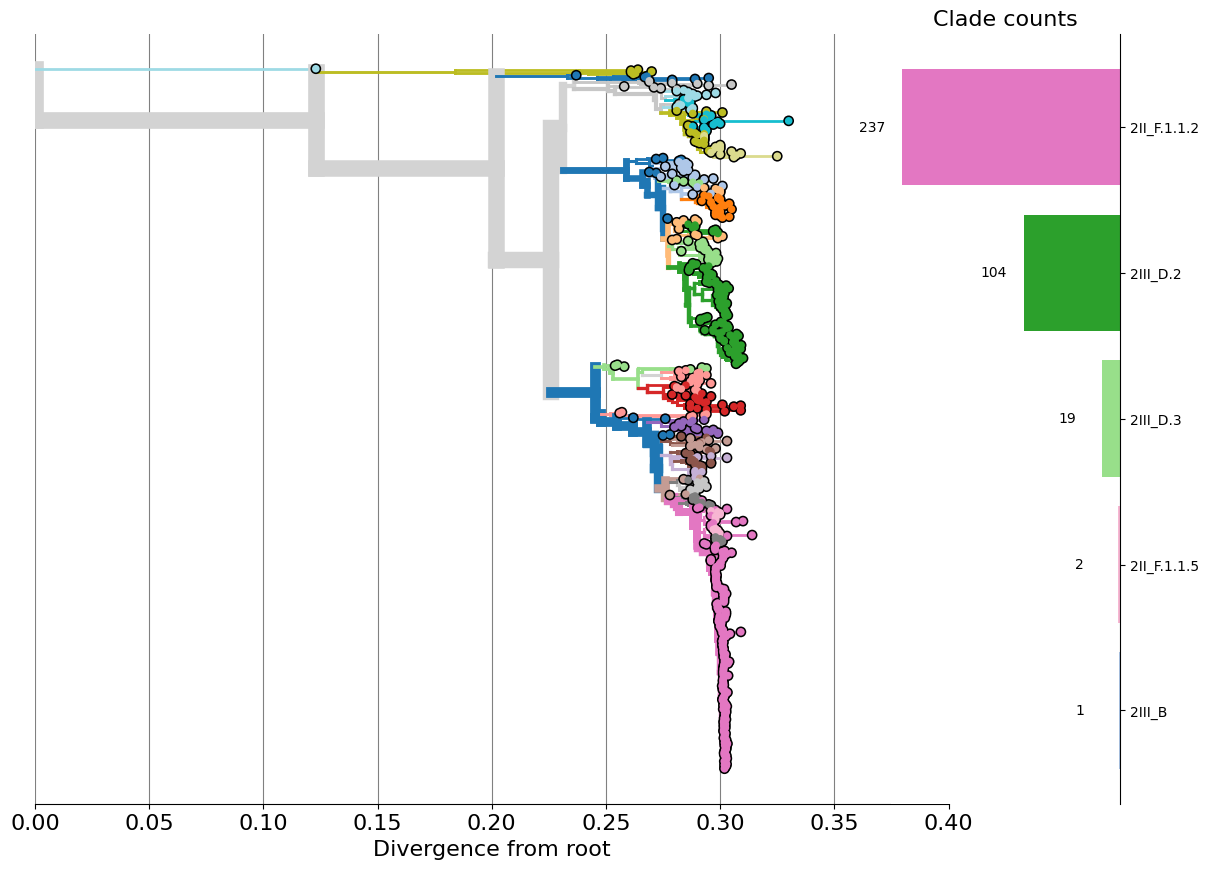

In [32]:
D3_nextstrain = '../Data/D2/Col_only/nextclade.auspice.json'

def prune(node, thresh=0.15):
    # only operate on dict-nodes
    if not isinstance(node, dict):
        return node
    # get the divergence (a float) for *this* branch
    div = node.get('node_attrs', {}) .get('div')
    if div is not None and div > thresh:
        return None
    # otherwise prune children
    if 'children' in node:
        kept = []
        for child in node['children']:
            pc = prune(child, thresh)
            if pc is not None:
                kept.append(pc)
        node['children'] = kept
    return node

# 1) Read the file
with open(D3_nextstrain, 'r') as fh:
    nx_json = json.load(fh)


# 2) Tell baltic to use 'div' as the node height
json_translation = {
    'absoluteTime': lambda node: node.traits['node_attrs']['div'],
    'name': 'name'
}

# 3) Load into baltic
ll, meta = bt.loadJSON(nx_json, json_translation=json_translation)

# make figure with tree on left and barplot on right
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=-0.1)
ax_tree = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])


L=len(list(filter(lambda k: k.branchType=='leaf',ll.Objects)))

clade_list = [
    k.traits['node_attrs']
      .get('clade_membership', {})
      .get('value')
    for k in ll.Objects if k.is_leaf()
]

# create a unique sorted list and assign colors from tab20
unique_clades = sorted({c for c in clade_list if c is not None})
palette = cm.get_cmap('tab20', len(unique_clades))
clade_color_map = {
    clade: mcolors.to_hex(palette(i))
    for i, clade in enumerate(unique_clades)
}

# register this map under 'clade_membership'
ll.cmap['clade_membership'] = clade_color_map

#Only count those that are from Colombia
clade_counts = Counter(
    node.traits['node_attrs']['clade_membership']['value']
    for node in ll.Objects
    if node.is_leaf()
       and len(node.name.split('/')) > 1
       and node.name.split('/')[1] == 'Colombia'
)
filtered = {clade: cnt for clade, cnt in clade_counts.items() if cnt >= 1}
clades, counts = zip(*sorted(filtered.items(), key=lambda x: x[1], reverse=True))
colors = [ll.cmap['clade_membership'][c] for c in clades]

# colour function using the newly registered map
def c_func(node):
    clade = node.traits['node_attrs'] \
               .get('clade_membership', {}) \
               .get('value')
    return ll.cmap['clade_membership'].get(clade, 'lightgrey')


x_attr = lambda k: k.absoluteTime
b_func=lambda k: 2+10.0*len(k.leaves)/float(L) if k.branchType=='node' else 2

# plotting
ll.plotTree(ax_tree, x_attr=x_attr, width=b_func, colour=c_func, zorder=20000)
ll.plotPoints(ax_tree, x_attr=x_attr, size=30, colour=c_func, zorder=20002)
for loc in ['left', 'right', 'top']:
    ax_tree.spines[loc].set_visible(False)
ax_tree.grid(axis='x', ls='-', color='grey')
ax_tree.tick_params(axis='y', size=0)
ax_tree.tick_params(axis='x', labelsize=16)
ax_tree.set_xlabel('Divergence from root', fontsize=16)
ax_tree.set_yticklabels([])
ax_tree.set_xlim(0, 0.4)

y = np.arange(len(clades))
ax_bar.barh(y, counts, color=colors)
ax_bar.set_yticks(y)
ax_bar.set_yticklabels(clades, fontsize=10)
ax_bar.invert_yaxis()

# move y‐labels to the right
ax_bar.yaxis.tick_right()
ax_bar.yaxis.set_label_position('right')
ax_bar.title.set_text('Clade counts')
ax_bar.title.set_size(16)
# make bars extend left
ax_bar.set_xlim(max(counts)*1.05, 0)

# annotate counts at end of each bar
offset = max(counts) * 0.2
for i, count in enumerate(counts):
    ax_bar.text(count + offset, i, str(count),
                va='center', ha='left', fontsize=10)

# drop x‐axis
ax_bar.xaxis.set_visible(False)
for loc in ['bottom', 'top', 'left']:
    ax_bar.spines[loc].set_visible(False)


#
plt.savefig('../Figures/Supplementary/Dengue2_Colombia.jpeg', dpi = 1200, bbox_inches='tight')
plt.show()